# Exponential decay fitting example

Demonstrates single- and double-exponential fits with the `Decay_exp` class using synthetic data.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from wara import decay_exponential as decay

Generate synthetic single-decay data with Gaussian noise.

True parameters: `A=1000`, `k=0.05`, `C=50`.

In [2]:
RNG = np.random.default_rng(42)

t = np.linspace(1, 100, 60)
noise = 15.0
y_single = decay.single_decay_plus_constant(t, A=1000, k=0.05, C=50)
y_single += RNG.normal(0, noise, size=len(t))
yerr_single = np.full_like(t, noise)

Fit and plot the single exponential decay.

[[Model]]
    Model(single_decay_plus_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 60
    # variables        = 3
    chi-square         = 35.7479165
    reduced chi-square = 0.62715643
    Akaike info crit   = -25.0711544
    Bayesian info crit = -18.7881208
    R-squared          = 0.99771682
[[Variables]]
    A:  992.842366 +/- 7.00484554 (0.71%) (init = 1005.8)
    k:  0.04977185 +/- 7.5025e-04 (1.51%) (init = 0.04805603)
    C:  51.5114683 +/- 3.00031667 (5.82%) (init = 40.26492)
[[Correlations]] (unreported correlations are < 0.100)
    C(k, C) = +0.7542
    C(A, k) = +0.4399


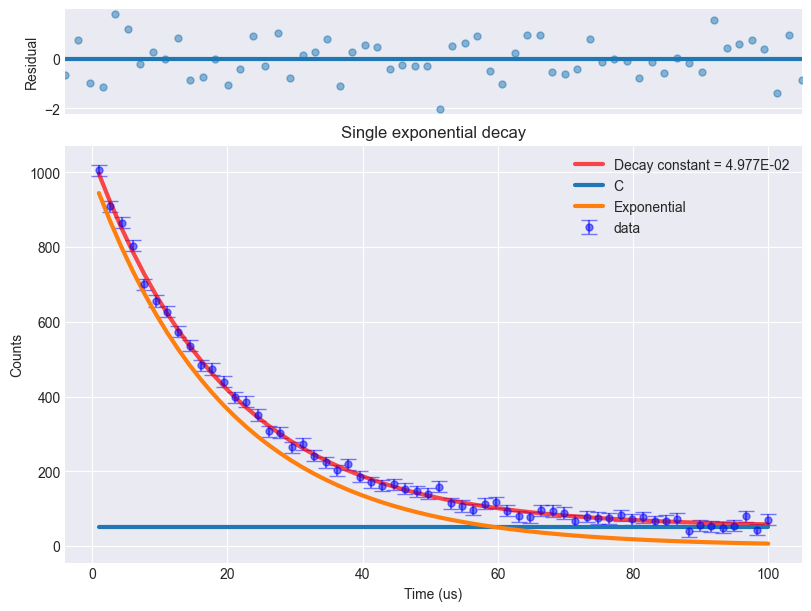

In [3]:
exp1 = decay.Decay_exp(x=t, y=y_single, yerr=yerr_single)
exp1.fit_single_decay()
print(exp1.fit_result.fit_report())

ax_fit, ax_res = exp1.plot(show_components=True)
ax_fit.set_title("Single exponential decay")
plt.show()

Generate synthetic double-decay data.

True parameters: `A1=700`, `k1=0.04`, `A2=300`, `k2=0.3`, `C=30`.

In [4]:
y_double = decay.double_decay_plus_constant(t, A1=700, A2=300, k1=0.04, k2=0.3, C=30)
y_double += RNG.normal(0, noise, size=len(t))
yerr_double = np.full_like(t, noise)

Fit and plot the double exponential decay.

[[Model]]
    Model(double_decay_plus_constant)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 60
    # variables        = 5
    chi-square         = 31.0556124
    reduced chi-square = 0.56464750
    Akaike info crit   = -29.5139010
    Bayesian info crit = -19.0421782
    R-squared          = 0.99715122
[[Variables]]
    A1:  693.198553 +/- 29.5993189 (4.27%) (init = 629.6885)
    A2:  260.581818 +/- 29.7450015 (11.41%) (init = 269.8665)
    k1:  0.03972437 +/- 0.00210621 (5.30%) (init = 0.06262739)
    k2:  0.23289765 +/- 0.04710493 (20.23%) (init = 0.3131369)
    C:   26.4981988 +/- 5.16855817 (19.51%) (init = 27.48768)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, k1) = +0.9051
    C(A1, k2) = +0.8983
    C(k1, C)  = +0.8839
    C(A2, k1) = -0.8274
    C(A1, A2) = -0.8172
    C(k1, k2) = +0.7717
    C(A2, C)  = -0.6696
    C(A1, C)  = +0.6511
    C(k2, C)  = +0.5582
    C(A2, k2) = -0.5458


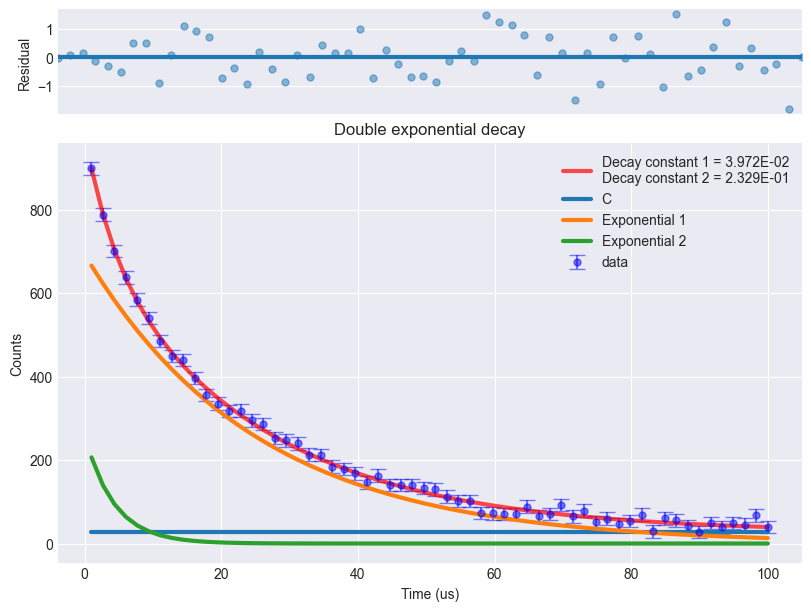

In [5]:
exp2 = decay.Decay_exp(x=t, y=y_double, yerr=yerr_double)
exp2.fit_double_decay()
print(exp2.fit_result.fit_report())

ax_fit, ax_res = exp2.plot(show_components=True)
ax_fit.set_title("Double exponential decay")
plt.show()